# Exercise 1 - Neural Network 

In [ ]:
import pandas as pd

data = pd.read_csv("../../dataset/Iris.csv")

In [ ]:
x = data.iloc[:,1:5].values
y = data.iloc[:,5]

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.2,
                                                 random_state=2)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10,10,10),
                    max_iter=1000)
mlp.fit(x_train,y_train)

In [ ]:
pred = mlp.predict(x_test)
pred

In [ ]:
score = mlp.score(x_test,y_test)
score

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

## MNIST Classification

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

import matplotlib.pyplot as plt

(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [ ]:
print(x_train.shape)
print(y_train.shape)

In [ ]:
x_train, x_test = x_train/255.0, x_test/255.0

In [ ]:
# model = models.Sequential([
#     layers.Flatten(input_shape=(28,28)),
#     layers.Dense(128,activation='relu'),
#     layers.Dropout(0.2),
#     layers.Dense(10,activation='softmax')
# ])
######################################################
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(784, activation='relu'),
    layers.Dense(10, activation='softmax')
    ])

In [ ]:
model.summary()

In [ ]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics =['accuracy'])
model.fit(x_train,y_train,epochs=10)

In [ ]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_acc}')

In [ ]:
import random
value=random.randint(0,10000-1)
print(value)

prediction = model.predict(x_test)
print(f'Predicted label: {tf.argmax(prediction[value])}')
print(f'True Label:{y_test[value]}')
plt.imshow(x_test[value],cmap='gray')
plt.title(f'Predicted:{tf.argmax(prediction[value])}, True: {y_test[value]}')
plt.show()

## CIFAR-10

In [ ]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
# from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.regularizers import l2
from tensorflow.keras.datasets import cifar10

# To load dataset from mnist
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
#

In [ ]:
train_images[0].size

In [ ]:
import numpy as np
np.shape(train_images)

In [ ]:
train_images = train_images/255.0
test_images = test_images/255.0

In [ ]:
train_images[0]

In [ ]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
classNo = 0
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i+classNo], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i+classNo][0]])

plt.show()

In [ ]:
model = keras.Sequential([
    # First Conv Block
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    # Second Conv Block
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    # Third Conv Block
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    # Fully Connected Layers
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images,train_labels, epochs=20,validation_data=(test_images,test_labels))

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

In [ ]:
import random
value=random.randint(0,10000-1)
print(value)
picture = 2

plt.imshow(test_images[value], cmap=plt.cm.binary)
plt.show()

result = model.predict(test_images[[value]])
print("Predicted result:", class_names[np.argmax(result)])
print("Actual result:", class_names[test_labels[value][0]])

## Flower Dataset

In [1]:
import numpy as np 
import os
import PIL

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt


dataset_path = '../../dataset/flower_photos/'
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42, 
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names 
print(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


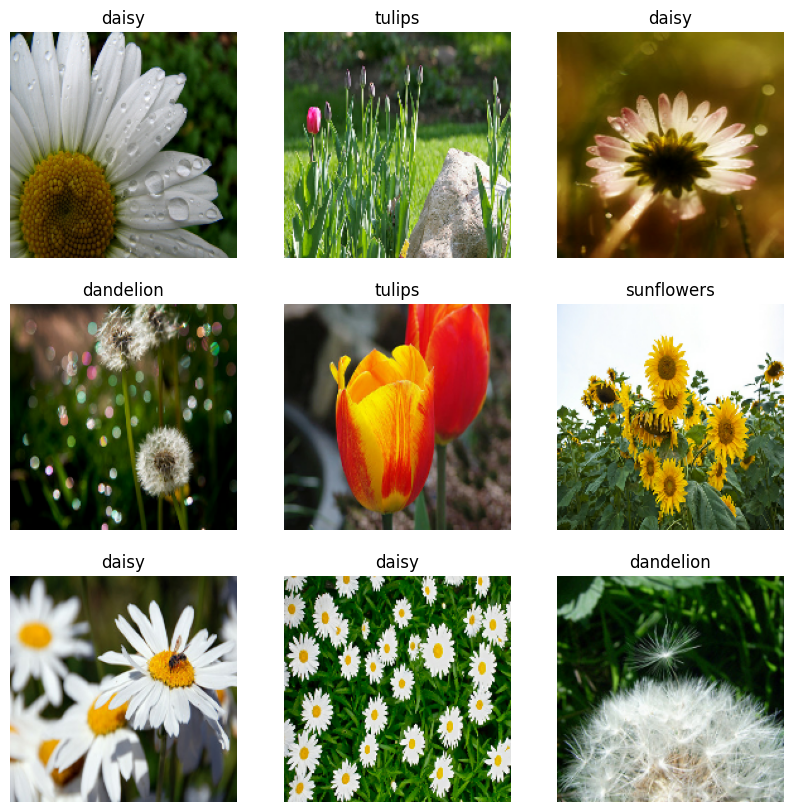

In [2]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [3]:
from tensorflow import keras
from tensorflow.keras.layers import RandomFlip,RandomRotation, RandomZoom

from tensorflow.keras.layers import Rescaling
normalization_layer=Rescaling(1./255)

# data_augmentation = keras.Sequential([
#     RandomFlip("horizontal",i
# 
# input_shape=(img_height,img_width,3)),
#     RandomRotation(0.1),
#     RandomZoom(0.1)
# ])

In [4]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in '[0,1]'.
print(np.min(first_image), np.max(first_image))

0.0 0.9906863


In [ ]:
# def normalize_img(img,label):
#     img=tf.cast(img,tf.float32)/255.0
#     return img,label
# train_ds = train_ds.map(normalize_img)
# val_ds=val_ds.map(normalize_img)

In [ ]:


model = models.Sequential([
    Rescaling(1.0/255,input_shape=(img_height,img_width,3)),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

In [ ]:
epochs = 20
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,
          epochs=epochs,
          validation_data=val_ds)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [5]:
from tensorflow.keras.layers import RandomFlip,RandomRotation, RandomZoom
data_augmentation = keras.Sequential([
    RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
        RandomRotation(0.1),
        RandomZoom(0.1)
    ])

c:\Users\Muhammad Afiq\anaconda3\envs\python311\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


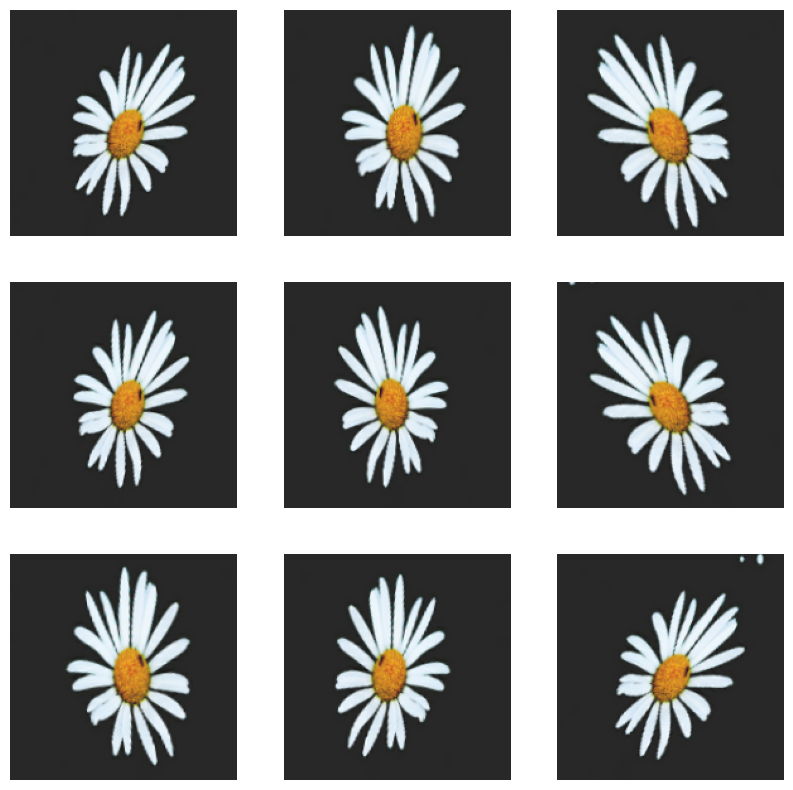

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [7]:
model = models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,301,157 (12.59 MB)

 Trainable params: 3,301,157 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
epochs = 50
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [13]:
history=model.fit(train_ds,
          epochs=epochs,
          validation_data=val_ds)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.8279 - loss: 0.4739 - val_accuracy: 0.7371 - val_loss: 0.8307
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.8282 - loss: 0.4613 - val_accuracy: 0.7452 - val_loss: 0.8591
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - accuracy: 0.8220 - loss: 0.4492 - val_accuracy: 0.7439 - val_loss: 0.8162
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.8402 - loss: 0.4234 - val_accuracy: 0.7534 - val_loss: 0.8105
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.8447 - loss: 0.3962 - val_accuracy: 0.7670 - val_loss: 0.7758
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.8529 - loss: 0.3742 - val_accuracy: 0.7534 - val_loss: 0.8400
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.8594 - loss: 0.3883 - val_accuracy: 0.7684 - val_loss: 0.8416
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.8652 - loss: 0.3736 - val_accu

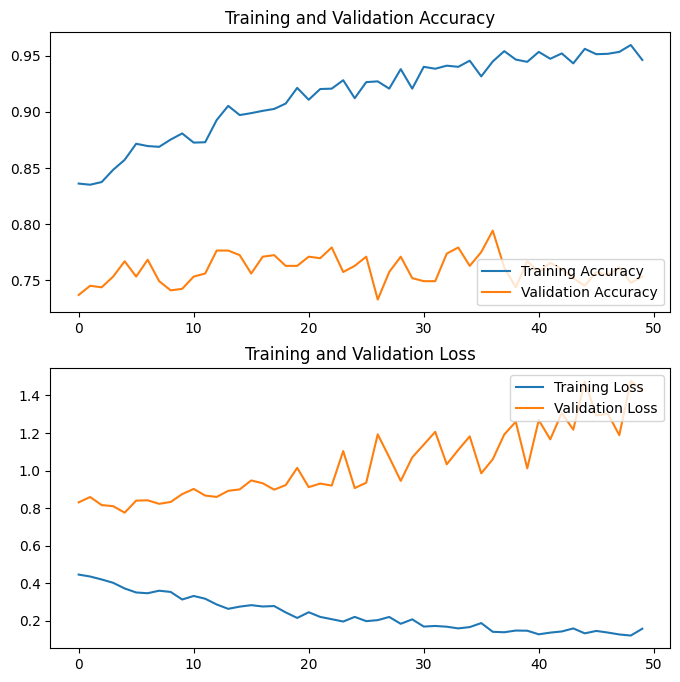

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [16]:
prediction_path = "download.jpg"

img = keras.preprocessing.image.load_img(
    prediction_path, target_size=(img_height,img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array,0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence"
    .format(class_names[np.argmax(score)],100*np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
This image most likely belongs to roses with a 40.43 percent confidence
